In [1]:
# This is a more complete version of Effiencies.py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.dates as mdates
import os
import urllib.request
import random
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from numpy import trapezoid
from scipy.signal import argrelmin

# Global Variables
Area = 2.0 #m**2
baseurl = 'https://gml.noaa.gov/aftp/data/radiation/baseline/spo'
InputPath = '../../DataFolder'
OutputPath = 'PlotsFolder/'

In [2]:
# import NOAA data function
def Import_NOAA_Data(year, day):
    input_1 = year
    input_2 = day
    # -----------------NOAA-----------------------------------
    NOAA = [] #list to hold dataframes
    for i in [ int(input_2) - 1, int(input_2)]: #previous day and current day to match the NZDT time and GMT time
        iid = '{0:03d}'.format(i) #format day of year to 3 digits (if Jan 1st, it should be 001, and so on)
        filename = f'{baseurl}/20{int(year)}/spo{int(year)}{iid}.dat' #construct the full filename
        print(filename) #print the filename being accessed
    
        try:
            file = urllib.request.urlopen(filename)
            data = file.read().decode('utf-8').split('\n') #read the file and split into lines
            #convert data to dataframe
            df = pd.DataFrame([row.split() for row in data[2:]])
            # print(dt)
            NOAA.append(df) #append dataframe to list
        except urllib.error.HTTPError:
            print(f"{filename} file not found") #print error if file not found
    
    # print('dir Irradiance data time correction')
    '''Direct Irradiance'''
    #define the direct irradiance and diffuse irradiance data with time correction for NZDT
    NOAAdir_ir_1 = NOAA[0][12]
    NOAAdir_ir_2 = NOAA[1][12]
    NOAAtemp = NOAA[0][38]
    # NOAAtemp = np.where(NOAAtemp == -9999.9, 0, 1)
    # print(f'NOAAtemp: {NOAAtemp}')
    # print(f'NOAAtemp sum: {np.sum(NOAAtemp)}')
    # concatenate the two days data with time correction
    NZDTdir_ir= pd.concat([NOAAdir_ir_1.iloc[660:1440], NOAAdir_ir_2.iloc[0:660]], axis = 0)
    #convert this to float
    NZDTdir_ir = NZDTdir_ir.astype(float)
    #remove nan values from NZDTdir_ir 
    NZDTdir_ir[NZDTdir_ir == -9999.9] = np.nan
    # NZDTdir_ir = np.array([random.randint(950, 1000) for _ in range(1440)]) # Generate a random integer between 950 and 1050
    # NZDTdir_ir = NZDTdir_ir.astype(float)
    # print(len(NZDTdir_ir))
    
    # print(NZDTdir_ir)
    
    # print('diff Irradiance data time correction')
    ''' Diffuse irradiance'''
    #diffuse irradiance
    NOAAdiff_ir_1 = NOAA[0][14]
    NOAAdiff_ir_2 = NOAA[1][14]
    
    # concatenate the two days data with time correction
    NZDTdiff_ir= pd.concat([NOAAdiff_ir_1.iloc[660:1440], NOAAdiff_ir_2.iloc[0:660]], axis = 0)
    NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    #remove nan values from NZDTdiff_ir 
    NZDTdiff_ir[NZDTdiff_ir == -9999.9] = np.nan #remove nan values
    # NZDTdiff_ir = np.array([random.randint(250, 350) for _ in range(1440)]) # Generate a random integer between 250 and 400
    # NZDTdiff_ir = NZDTdiff_ir.astype(float) #convert this to float
    
    ''' Upwelling irradiance'''
    #upwelling irradiance
    NOAAup_ir_1 = NOAA[0][10] 
    NOAAup_ir_2 = NOAA[1][10]
    NZDTup_ir= pd.concat([NOAAup_ir_1.iloc[660:1440], NOAAup_ir_2.iloc[0:660]], axis = 0) # concatenate the two days data with time correction
    NZDTup_ir = NZDTup_ir.astype(float)
    #remove nan values from NZDTup_ir 
    NZDTup_ir[NZDTup_ir == -9999.9] = np.nan
    # NZDTup_ir = np.array([random.randint(500, 600) for _ in range(1440)]) # Generate a random integer between 50 and 150
    # NZDTup_ir = NZDTup_ir.astype(float)
    
    '''Time List'''
    # print(NZDTdiff_ir)
    # Create a range of timestamps with a frequency of 1 minute ('min')
    times_list = pd.date_range("00:00:00", periods=1440, freq="min")
    
    # Format as HH:MM:SS strings
    NOAA_time = times_list.strftime("%H:%M:%S").tolist()    
    NOAA_time = pd.to_timedelta(pd.Series(NOAA_time))
    NOAA_time = NOAA_time.astype(str).str.split().str[-1]
    
    #time list for the device data
    times_list_device = pd.date_range("00:00:00", periods=2880, freq="min")
    
    # Format as HH:MM:SS strings
    device_time = times_list_device.strftime("%H:%M:%S").tolist()    
    device_time = pd.to_timedelta(pd.Series(device_time))
    device_time = device_time.astype(str).str.split().str[-1]
    
    # print(NOAA_time[:10],file_103['Time'][:10])
    #Calculate the solar angle for the given day of the year, this is from the solar angle formula
    

    # ---------------------------------------------------------------
    return NZDTdir_ir,NZDTdiff_ir, NZDTup_ir, NOAA_time

In [3]:
# import panel data function
def Import_Panel_Data(year, day):
    input_1 = year
    input_2 = day
    # --------REAL PANEL DATA-------------
    #Read the CSV files based on user input
    file_101 = pd.read_csv(f"{InputPath}/spo_dev101_{input_1}_{input_2}.csv",delimiter=',')
    file_103 = pd.read_csv(f"{InputPath}/spo_dev103_{input_1}_{input_2}.csv",delimiter=',')
    
    # Rename the Device ID column to voltage and Voltage to Current
    file_101.rename(columns = {'Device ID': 'V', 'Voltage': 'A'}, inplace=True)
    file_103.rename(columns = {'Device ID': 'V', 'Voltage': 'A'}, inplace=True) # There is a mismatch in the file so voltage column contains current and Device ID contains voltage
    
    # Each file has the data for more than just the day it is. We want to remove these extra dataS
    
    def date2num(date_str): # Renamed 'date' to 'date_str' to avoid confusion with the datetime.date object
        # 26 # first conver the xxxx-xx-xx format to date(xxxx, xx, xx)
    
        # You can skip splitting the string and go directly to parsing:
        date_object = datetime.strptime(date_str, '%Y-%m-%d').date()
        
        # 29 # return the day of the year (%j) as an integer
        # The strftime method returns a string, so we convert it to an integer.
        return int(date_object.strftime('%j'))
    # print(f'DEBUG: {input_2}')
    date = file_101['Date']
    NumberDate = date.apply(date2num)
    mask_to_keep =  NumberDate <= int(input_2)
    file_101 = file_101[mask_to_keep]
    # print(f'DEBUG: {mask_to_keep}')
    # print(f'DEBUG: {NumberDate}')
    
    date = file_103['Date']
    NumberDate = date.apply(date2num)
    mask_to_keep = NumberDate <= int(input_2)
    file_103 = file_103[mask_to_keep]
    
    #Extract time, voltage and current data
    
    time_101 = file_101['Time']
    voltage_101 = file_101['V'] 
    current_101 = file_101['A'] 
    
    time_103 = file_103['Time']
    voltage_103 = file_103['V'] 
    current_103 = file_103['A'] 
    
    power_101 = voltage_101 * current_101
    power_103 = voltage_103 * current_103
    # -----------------------------

    # print(f'len(power_101) = {len(power_101)}')
    return power_101, power_103, time_101, time_103

In [5]:
# year = 25
# day  = 346

Day_Range2025 = np.arange(334, 366, 1)

Conversion_Factor_Tuples = []
Mean_Irradiance_Tuples = []
Mean_Power_Tuples = []
for day in Day_Range2025:
    try:
        year = 25
        Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, NOAA_time = Import_NOAA_Data(year,day)
        power_101_og, power_103_og, __, __ = Import_Panel_Data(year, day)
        # not using 103 but just in case:
        power_103 = power_103_og
        # get the time_101 from day 345 because it is complete
        __,__,time_101,__ = Import_Panel_Data(25,365)
        # print(len(time_101))
        
        
        power_101_og = power_101_og.to_numpy()
        print(f'og: {len(power_101_og)}')
        # print(len(power_101))
        # if power_101 is too small, we pad with nan
        if len(power_101_og) <= 2880:
            difference = 2880 - len(power_101_og)
            power_101 = power_101_og
            for i in np.arange(0,difference,1):
                power_101 = np.append(power_101, np.nan)
        # print(len(power_101))
        
        # 2 component fit + 1 sharpness
        
        # Make a model for power data using irradiance
        
        # use sigmoids for smooth transition from front to back of panel
        def sigmoid(x, sharpness, shift):
            return np.array(1 / (1 + np.exp(-(1/sharpness)*(x + shift))))
         
        
        def model(time, Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, effs, sharpness):
            eff_direct = effs[0]
            eff_isotropic = effs[1]
            efficiency_back = .7
        
            Change_Time_1 = 280
            Change_Time_2 = Change_Time_1 + 1440/2
            Angular_Dependance_Front = np.array(np.cos(np.pi/(Change_Time_2 - Change_Time_1)*(time - (Change_Time_1 + Change_Time_2)/2)))
            Angular_Dependance_Back = np.array(-Angular_Dependance_Front)
        
            # create front of panel simulation (I did tricky math to get these)
            # Directional components:
            Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, -Change_Time_1)*sigmoid(-time, sharpness, Change_Time_2)
            Back  = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, -Change_Time_2)*sigmoid(-time, sharpness, 2*Change_Time_2 - Change_Time_1)
            Secondary_Front = eff_direct*Direct_Irradiance*Angular_Dependance_Front*sigmoid(time, sharpness, Change_Time_1 - 2*Change_Time_2)*sigmoid(-time, sharpness, 3*Change_Time_2 - Change_Time_1)
            Secondary_Back = .7*eff_direct*Direct_Irradiance*Angular_Dependance_Back*sigmoid(time, sharpness, Change_Time_2 - 2*Change_Time_1)*sigmoid(-time, sharpness, Change_Time_1)
            Total_Directional_Irradiance = Front + Back + Secondary_Front + Secondary_Back
        
            
            # add directional to the isotropic components:
            Total_Irradiance = Total_Directional_Irradiance + eff_isotropic*Diffuse_Irradiance + eff_isotropic*Upwelling_Irradiance
        
            # Multiply by area to get total power
            Total_Power = Total_Irradiance*Area
        
            # constraint of device resistor:
        
            Max_Power = 420
            Total_Power = np.clip(Total_Power, 0, Max_Power)
            return Total_Power
        
        # we want to fit the efficiencies and the sharpness
        Direct_Irradiance, Diffuse_Irradiance, Upwelling_Irradiance, NOAA_time = Import_NOAA_Data(year,day)
        def Fit_Model(time, eff_dir, eff_isotropic, sharpness):
            '''
            wrapping function for model
            '''
            effs = [eff_dir, eff_isotropic]
            sim_power = model(np.linspace(0,1440,1440), np.array(Direct_Irradiance), np.array(Diffuse_Irradiance), np.array(Upwelling_Irradiance), effs, 50)
            sim_power_2880 = np.repeat(sim_power, 2)
            if len(sim_power_2880) > len(power_101_og):
                sim_power_data_length = sim_power_2880[:len(power_101_og)]
                # print(f'len(sim_power_data_length) = {len(sim_power_data_length)}')
                nanmask = ~np.isnan(power_101_og)
                # print(f'len(sim_power_data_length[nanmask]) = {len(sim_power_data_length[nanmask])}')
                sim_power_2880 = sim_power_data_length[nanmask]
            return sim_power_2880
        
        
        print(len(power_101))
        # Using lmfit to fit
        from lmfit import Model
        from lmfit import fit_report
        mod = Model(Fit_Model)
        
        params = mod.make_params([.22,.01, 50]) # using the diff and upwelling from edges
        print(mod.param_names,mod.independent_vars)
        
        params['eff_dir'].set(min=0, max=1)     
        params['eff_isotropic'].set(min=0, max=1)
        params['sharpness'].set(value = 50, min = .1, max = 100)
        
        nanmask = ~np.isnan(power_101_og)
        
        DayArrayPowerLength = len(power_101_og[nanmask])
        x = np.arange(0,DayArrayPowerLength,1)
        
        # remove the nan values from power_101
        y = power_101_og[nanmask]
        
        # print(f'len(x) = {len(x)}')
        # print(f'len(y) = {len(y)}')
        
        
        result = mod.fit(y, params, time=x, method='nelder', nan_policy = 'omit')
        
        # Print a comprehensive report of the results
        # print(result.fit_report())
        
        # Access the best-fit values
        # print(f"Best Amplitude: {result.params['eff_dir'].value}")
        
        
        fitted_dir_eff = result.params['eff_dir'].value
        fitted_isotropic_eff = result.params['eff_isotropic'].value
        fitted_sharpness = result.params['sharpness'].value
        
        
        print()
        print()
        # print(f'fitted_dir_eff = {fitted_dir_eff}')
        # print(f'fitted_isotropic_eff = {fitted_isotropic_eff}')
        # print(f'fitted_sharpness = {fitted_sharpness}')
        
        # print(fit_report(result))
        Conversion_Factor_Tuples.append((fitted_dir_eff, fitted_isotropic_eff))
    except:
        Conversion_Factor_Tuples.append((np.nan,np.nan))
print(Conversion_Factor_Tuples)

https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25333.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25334.dat
og: 2879
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25333.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25334.dat
2880
 - Adding parameter "eff_dir"
 - Adding parameter "eff_isotropic"
 - Adding parameter "sharpness"
['eff_dir', 'eff_isotropic', 'sharpness'] ['time']


https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25334.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25335.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25335.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25336.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25336.dat
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25337.dat
og: 828
https://gml.noaa.gov/aftp/data/radiation/baseline/spo/2025/spo25336.dat
https://gml.noaa.gov/aftp/data/radi

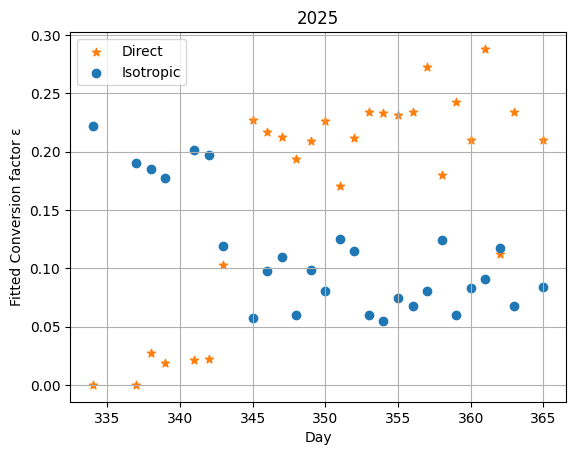

In [19]:
Direct_Conversion_Factors_0, Isotropic_Conversion_Factors_0 = zip(*Conversion_Factor_Tuples)
Direct_Conversion_Factors = list(Direct_Conversion_Factors_0)
Isotropic_Conversion_Factors = list(Isotropic_Conversion_Factors_0)


plt.scatter(Day_Range2025, Direct_Conversion_Factors, label = 'Direct', color = 'tab:orange', marker = '*')
plt.scatter(Day_Range2025, Isotropic_Conversion_Factors, label = 'Isotropic', color = 'tab:blue')
plt.legend()
plt.title(2025)
plt.xlabel('Day')
plt.ylabel('Fitted Conversion factor ε')
plt.grid('on')
plt.show()